<a href="https://colab.research.google.com/github/ericyoc/behavioral_keystroke_dynamics_baseling_poc/blob/main/keystroke_dynamics_benchmark_poc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import urllib.request

# Download dataset if not already present
dest = '/content/drive/MyDrive/DSL-StrongPasswordData.csv'
if not os.path.exists(dest):
    print("Downloading CMU dataset...")
    urllib.request.urlretrieve(
        'http://www.cs.cmu.edu/~keystroke/DSL-StrongPasswordData.csv',
        dest
    )
    print("Download complete.")

Download complete.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 51 subjects, 31 features each

Finding optimal EER threshold for subject: s002...
  EER Threshold : 0.9194
  EER           : 28.13%

Benchmarking all 51 users using EER threshold...

--- Benchmark Results (mean across all users) ---
Method                  Avg FRR    Avg FAR
Dot Product              28.78%     28.98%
Euclidean                24.36%     24.21%

--- Literature Benchmarks (CMU, 2009) ---
Method                  Avg FRR    Avg FAR
Manhattan (scaled)         9.6%       9.1%
Mahalanobis               19.3%       8.1%
SVM                        2.6%      10.0%


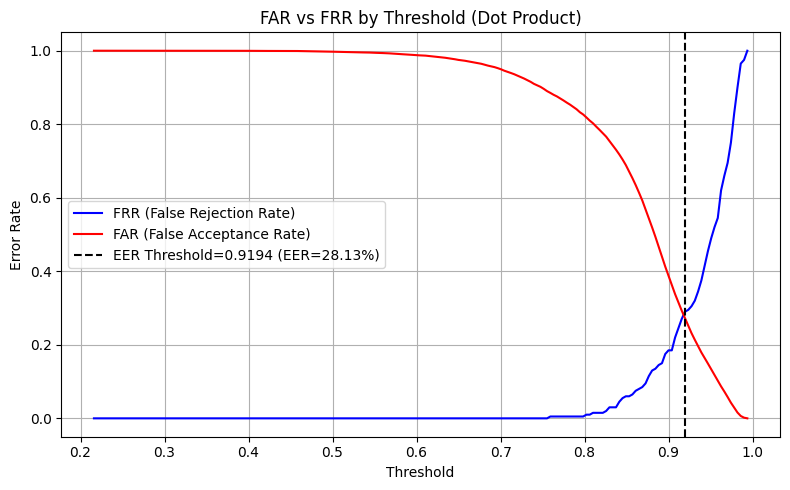

Saved: threshold_sweep.png


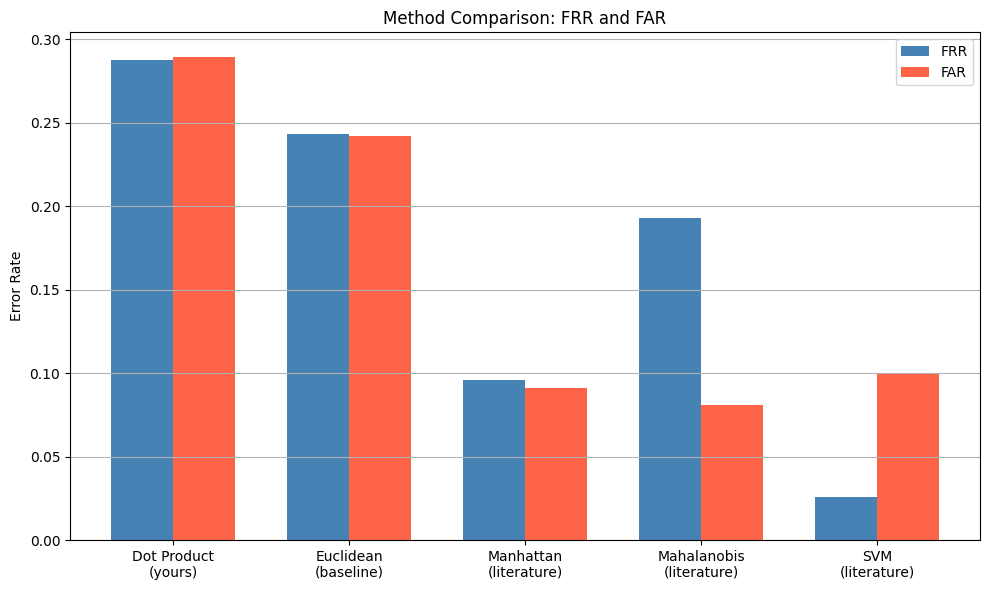

Saved: benchmark_comparison.png


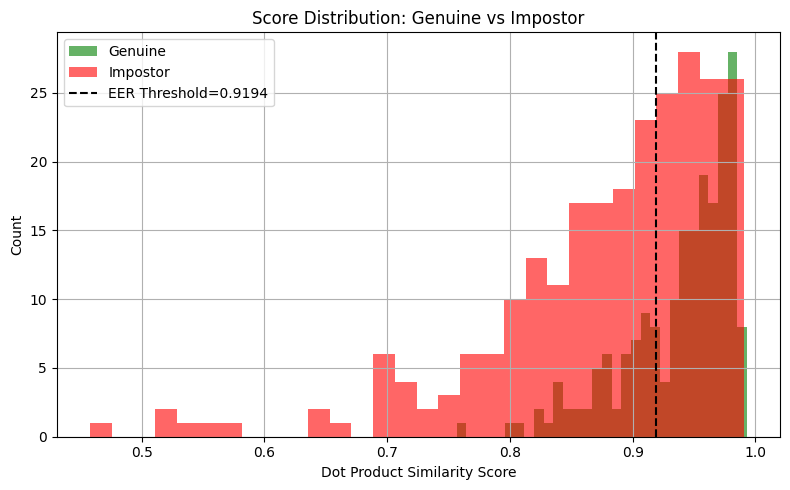

Saved: score_distribution.png

Done. All plots saved to Google Drive.


In [4]:
# ============================================================
# Keystroke Behavioral Authentication
# CMU Keystroke Dynamics Dataset + Dot Product Similarity
# ============================================================
# Setup:
#   1. Run in Google Colab
#   2. Dataset is downloaded automatically from CMU

from google.colab import drive
import os
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Constants
# ============================================================

DATA_PATH  = '/content/drive/MyDrive/DSL-StrongPasswordData.csv'
TRAIN_RATIO = 0.5


# ============================================================
# Core Functions
# ============================================================

def get_vectors(df, subject, feature_cols):
    return df[df['subject'] == subject][feature_cols].values

def build_profile(vectors):
    """Average training samples into one profile vector."""
    return np.mean(vectors, axis=0)

def dot_similarity(profile, vector):
    """Cosine-style dot product similarity. Range: -1 to 1."""
    p = profile / (np.linalg.norm(profile) + 1e-10)
    v = vector / (np.linalg.norm(vector) + 1e-10)
    return np.dot(p, v)

def euclidean_similarity(profile, vector):
    """Euclidean distance converted to similarity score."""
    dist = np.linalg.norm(profile - vector)
    return 1 / (1 + dist)

def get_score(profile, vector, method='dot'):
    if method == 'dot':
        return dot_similarity(profile, vector)
    return euclidean_similarity(profile, vector)

def evaluate_user(df, feature_cols, subjects, genuine_subject, threshold, method='dot'):
    genuine_vecs = get_vectors(df, genuine_subject, feature_cols)
    split = int(len(genuine_vecs) * TRAIN_RATIO)
    profile = build_profile(genuine_vecs[:split])
    test_genuine = genuine_vecs[split:]

    # FRR
    rejected = sum(1 for v in test_genuine if get_score(profile, v, method) < threshold)
    frr = rejected / len(test_genuine)

    # FAR
    false_accepts, total = 0, 0
    for subject in subjects:
        if subject == genuine_subject:
            continue
        for v in get_vectors(df, subject, feature_cols):
            if get_score(profile, v, method) >= threshold:
                false_accepts += 1
            total += 1

    far = false_accepts / total if total > 0 else 0
    return frr, far, profile, genuine_vecs, split


# ============================================================
# EER Detection
# ============================================================

def find_eer(df, feature_cols, subjects, genuine_subject, method='dot', steps=200):
    """Sweep thresholds and find the Equal Error Rate (EER) threshold."""
    genuine_vecs = get_vectors(df, genuine_subject, feature_cols)
    split = int(len(genuine_vecs) * TRAIN_RATIO)
    profile = build_profile(genuine_vecs[:split])
    test_genuine = genuine_vecs[split:]

    # Collect all scores
    genuine_scores  = [get_score(profile, v, method) for v in test_genuine]
    impostor_scores = []
    for subject in subjects:
        if subject == genuine_subject:
            continue
        for v in get_vectors(df, subject, feature_cols):
            impostor_scores.append(get_score(profile, v, method))

    all_scores = genuine_scores + impostor_scores
    thresholds = np.linspace(min(all_scores), max(all_scores), steps)

    frrs, fars = [], []
    for t in thresholds:
        frr = sum(1 for s in genuine_scores  if s < t) / len(genuine_scores)
        far = sum(1 for s in impostor_scores if s >= t) / len(impostor_scores)
        frrs.append(frr)
        fars.append(far)

    # Find crossover point
    frrs, fars = np.array(frrs), np.array(fars)
    idx = np.argmin(np.abs(frrs - fars))
    eer_threshold = thresholds[idx]
    eer = (frrs[idx] + fars[idx]) / 2

    return eer_threshold, eer, thresholds, frrs, fars


# ============================================================
# Visualization Functions
# ============================================================

def plot_threshold_sweep(thresholds, frrs, fars, eer_threshold, eer):
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, frrs, 'b-', label='FRR (False Rejection Rate)')
    plt.plot(thresholds, fars, 'r-', label='FAR (False Acceptance Rate)')
    plt.axvline(eer_threshold, color='black', linestyle='--', label=f'EER Threshold={eer_threshold:.4f} (EER={eer:.2%})')
    plt.xlabel('Threshold')
    plt.ylabel('Error Rate')
    plt.title('FAR vs FRR by Threshold (Dot Product)')
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/threshold_sweep.png', dpi=150)
    plt.show()
    print("Saved: threshold_sweep.png")

def plot_benchmark_comparison(dot_frrs, dot_fars, euc_frrs, euc_fars):
    methods = ['Dot Product\n(yours)', 'Euclidean\n(baseline)', 'Manhattan\n(literature)', 'Mahalanobis\n(literature)', 'SVM\n(literature)']
    avg_frr = [np.mean(dot_frrs), np.mean(euc_frrs), 0.096, 0.193, 0.026]
    avg_far = [np.mean(dot_fars), np.mean(euc_fars), 0.091, 0.081, 0.100]

    x = np.arange(len(methods))
    width = 0.35
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - width/2, avg_frr, width, label='FRR', color='steelblue')
    ax.bar(x + width/2, avg_far, width, label='FAR', color='tomato')
    ax.set_ylabel('Error Rate')
    ax.set_title('Method Comparison: FRR and FAR')
    ax.set_xticks(x); ax.set_xticklabels(methods)
    ax.legend(); ax.grid(axis='y')
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/benchmark_comparison.png', dpi=150)
    plt.show()
    print("Saved: benchmark_comparison.png")

def plot_score_distribution(df, feature_cols, subjects, genuine_subject, profile, genuine_vecs, split, eer_threshold):
    genuine_scores  = [dot_similarity(profile, v) for v in genuine_vecs[split:]]
    impostor_scores = []
    for subject in subjects:
        if subject == genuine_subject:
            continue
        for v in get_vectors(df, subject, feature_cols)[:5]:
            impostor_scores.append(dot_similarity(profile, v))

    plt.figure(figsize=(8, 5))
    plt.hist(genuine_scores,  bins=30, alpha=0.6, color='green', label='Genuine')
    plt.hist(impostor_scores, bins=30, alpha=0.6, color='red',   label='Impostor')
    plt.axvline(eer_threshold, color='black', linestyle='--', label=f'EER Threshold={eer_threshold:.4f}')
    plt.xlabel('Dot Product Similarity Score')
    plt.ylabel('Count')
    plt.title('Score Distribution: Genuine vs Impostor')
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/score_distribution.png', dpi=150)
    plt.show()
    print("Saved: score_distribution.png")


# ============================================================
# Main
# ============================================================

def main():
    # Mount Google Drive
    drive.mount('/content/drive')

    # Download dataset if not present
    if not os.path.exists(DATA_PATH):
        print("Downloading CMU dataset...")
        urllib.request.urlretrieve(
            'http://www.cs.cmu.edu/~keystroke/DSL-StrongPasswordData.csv',
            DATA_PATH
        )
        print("Download complete.")

    # Load dataset
    df = pd.read_csv(DATA_PATH)
    feature_cols = [c for c in df.columns if c not in ['subject', 'sessionIndex', 'rep']]
    subjects = df['subject'].unique()
    print(f"Loaded {len(subjects)} subjects, {len(feature_cols)} features each")

    # Find EER threshold automatically for first subject
    genuine_subject = subjects[0]
    print(f"\nFinding optimal EER threshold for subject: {genuine_subject}...")
    eer_threshold, eer, thresholds, frrs, fars = find_eer(
        df, feature_cols, subjects, genuine_subject, method='dot'
    )
    print(f"  EER Threshold : {eer_threshold:.4f}")
    print(f"  EER           : {eer:.2%}")

    # Benchmark all users using EER threshold
    print("\nBenchmarking all 51 users using EER threshold...")
    dot_frrs, dot_fars = [], []
    euc_frrs, euc_fars = [], []

    for subject in subjects:
        # Find each user's own EER threshold
        t, _, _, _, _ = find_eer(df, feature_cols, subjects, subject, method='dot')
        frr, far, _, _, _ = evaluate_user(df, feature_cols, subjects, subject, t, method='dot')
        dot_frrs.append(frr); dot_fars.append(far)

        t, _, _, _, _ = find_eer(df, feature_cols, subjects, subject, method='euclidean')
        frr, far, _, _, _ = evaluate_user(df, feature_cols, subjects, subject, t, method='euclidean')
        euc_frrs.append(frr); euc_fars.append(far)

    # Print results
    print("\n--- Benchmark Results (mean across all users) ---")
    print(f"{'Method':<20} {'Avg FRR':>10} {'Avg FAR':>10}")
    print(f"{'Dot Product':<20} {np.mean(dot_frrs):>10.2%} {np.mean(dot_fars):>10.2%}")
    print(f"{'Euclidean':<20} {np.mean(euc_frrs):>10.2%} {np.mean(euc_fars):>10.2%}")

    print("\n--- Literature Benchmarks (CMU, 2009) ---")
    print(f"{'Method':<20} {'Avg FRR':>10} {'Avg FAR':>10}")
    print(f"{'Manhattan (scaled)':<20} {'9.6%':>10} {'9.1%':>10}")
    print(f"{'Mahalanobis':<20} {'19.3%':>10} {'8.1%':>10}")
    print(f"{'SVM':<20} {'2.6%':>10} {'10.0%':>10}")

    # Visualizations
    frr, far, profile, genuine_vecs, split = evaluate_user(
        df, feature_cols, subjects, genuine_subject, eer_threshold, method='dot'
    )

    plot_threshold_sweep(thresholds, frrs, fars, eer_threshold, eer)
    plot_benchmark_comparison(dot_frrs, dot_fars, euc_frrs, euc_fars)
    plot_score_distribution(df, feature_cols, subjects, genuine_subject, profile, genuine_vecs, split, eer_threshold)

    print("\nDone. All plots saved to Google Drive.")


if __name__ == "__main__":
    main()